# Notebook 7 – Programme 2 : Lecture automatique des formulaires
**Projet Computer Vision IG.2405 – 2026**

Ce notebook exécute et analyse le **Programme 2 complet** :

```
autoReadForm(EXAM_FORMXX_PDF, STUDENT_CLASS_SIGNATURES, EXAM_FORMXX_RESULTS)
```

Pour chaque PDF, génère un fichier `.xlsx` avec 2 onglets :
- **PAGE-01** : informations de la page 1 (Module, Professeur, Date, Student ID, Signature, ...)
- **EXAM** : réponses aux questions (CHOIX A-H, MANTISSE, EXPOSANT, UNITÉ)

In [1]:
import sys, os

# Racine du projet (fonctionne depuis notebooks/ ou depuis la racine)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DATA_ROOT = os.path.join(ROOT, 'PROJECT 2026 -DATABASE-20260518')
print(f'Racine projet : {ROOT}')
print(f'Base de donnees : {DATA_ROOT}')

Racine projet : /home/felix/Documents/ProjetComputerVisionYann/Computer-Vision
Base de donnees : /home/felix/Documents/ProjetComputerVisionYann/Computer-Vision/PROJECT 2026 -DATABASE-20260518


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from autoReadForm import autoReadForm, autoReadFormID
from utils.pdf_utils import pdf_to_images, count_pdf_pages
from utils.grid_decoder import normalize_page, extract_cryptogram
from utils.page1_parser import parse_page1, compare_cryptograms
from utils.exam_parser import parse_exam_pages, questions_to_exam_rows, detect_question_blocks

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
FORM_DIR    = os.path.join('PROJECT 2026 -DATABASE-20260518', 'FORM1')
SIG_DIR     = os.path.join('PROJECT 2026 -DATABASE-20260518', 'SIGNATURES')
RESULTS_DIR = 'EXAM_FORM1_RESULTS'
EXAM_START  = 4  # page 5 = index 4

os.makedirs(RESULTS_DIR, exist_ok=True)

pdf_files = sorted([f for f in os.listdir(FORM_DIR) if f.lower().endswith('.pdf')])
print(f'{len(pdf_files)} formulaires PDF à traiter')

43 formulaires PDF à traiter


## 1. Structure d'un formulaire PDF

Visualisation de toutes les pages d'un formulaire exemple.

PDF : EXAM_FORM1_19283.pdf (7 pages)


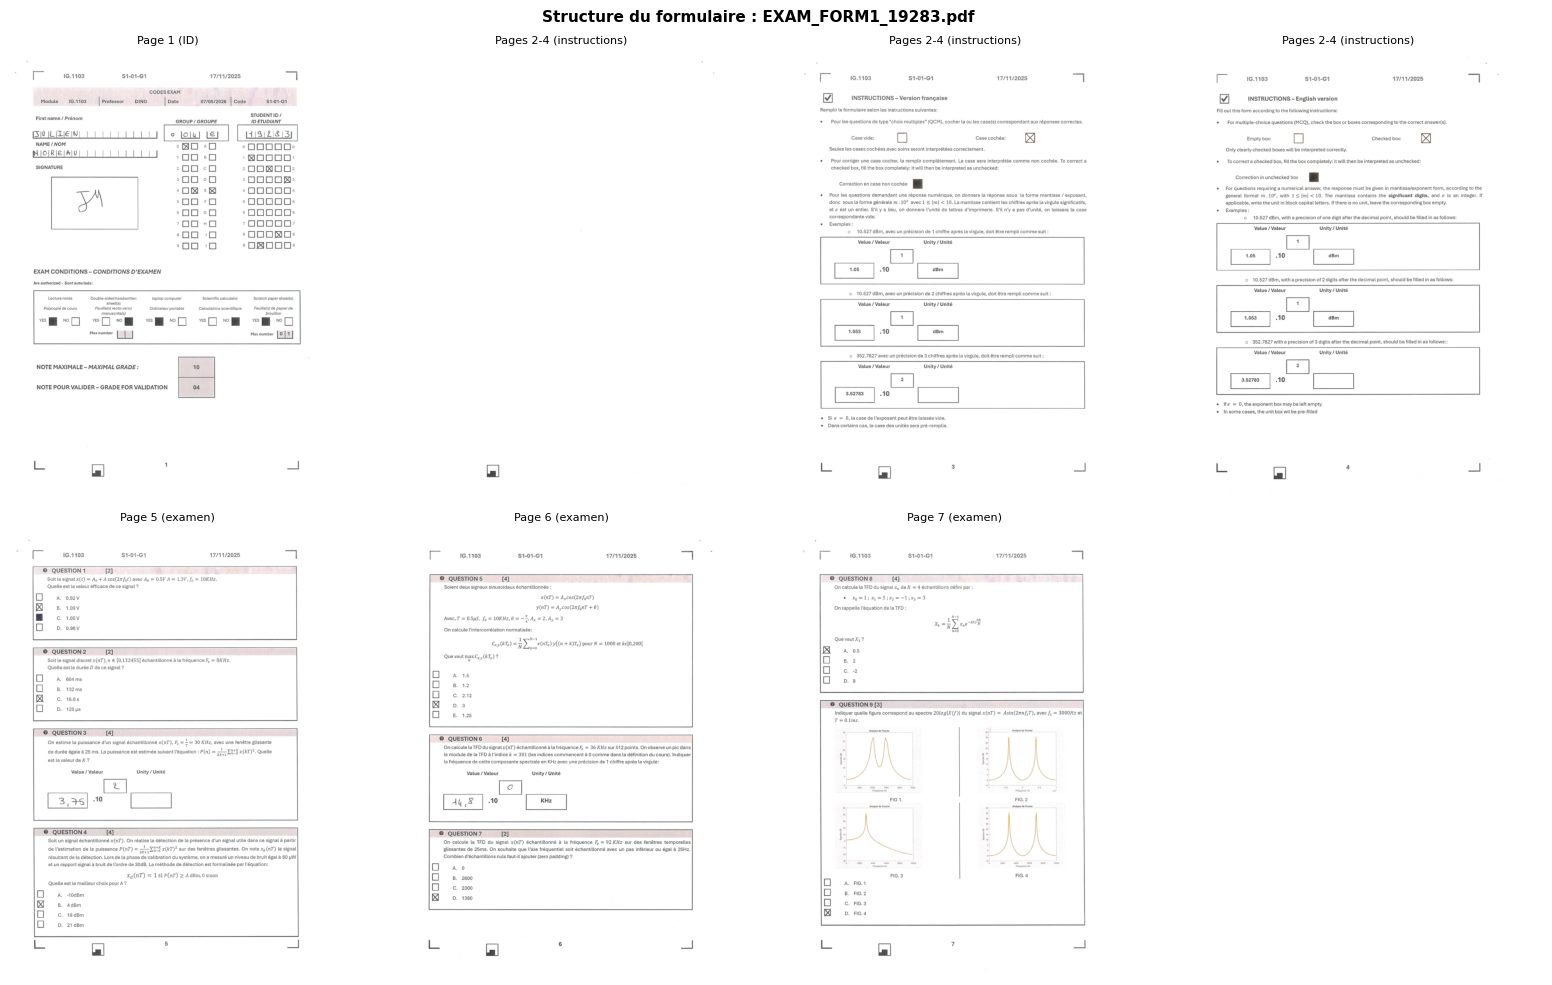

In [3]:
sample_pdf_path = os.path.join(FORM_DIR, pdf_files[0])
n_pages = count_pdf_pages(sample_pdf_path)
print(f'PDF : {pdf_files[0]} ({n_pages} pages)')

pages = pdf_to_images(sample_pdf_path, dpi=100)

# Afficher toutes les pages (miniatures)
n_cols = min(4, n_pages)
n_rows = (n_pages + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else [axes]
    axes = axes[0] if isinstance(axes[0], np.ndarray) else axes
axes_flat = np.array(axes).flatten() if n_rows > 1 else (axes if hasattr(axes, '__iter__') else [axes])

for i, page in enumerate(pages):
    if i >= len(axes_flat):
        break
    axes_flat[i].imshow(cv2.cvtColor(page, cv2.COLOR_BGR2RGB))
    label = 'Page 1 (ID)' if i == 0 else ('Pages 2-4 (instructions)' if i < 4 else f'Page {i+1} (examen)')
    axes_flat[i].set_title(label, fontsize=8)
    axes_flat[i].axis('off')

for j in range(len(pages), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle(f'Structure du formulaire : {pdf_files[0]}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Parsing de la Page 1

In [4]:
# Cryptogrammes des pages 2+
crypto_pages = []
for pg_img in pages[1:]:
    norm_pg = normalize_page(pg_img)
    c = extract_cryptogram(norm_pg)
    if c is not None and c.size > 0:
        crypto_pages.append(c)

print(f'{len(crypto_pages)} cryptogrammes extraits des pages 2+')

# Parser la page 1
page1_data = parse_page1(pages[0], desc_db=None, crypto_pages=crypto_pages)

print('\n=== Données PAGE-01 ===')
fields = [
    ('Module',                 'module'),
    ('Professeur',             'professor'),
    ('Date',                   'date'),
    ('Code',                   'code'),
    ('Notes de cours',         'notes_cours'),
    ('Notes manuscrites',      'notes_manuscrites'),
    ('Ordinateur',             'ordinateur'),
    ('Calculatrice',           'calculatrice'),
    ('Brouillon',              'brouillon'),
    ('Note maximale',          'note_max'),
    ('Note pour valider',      'note_valid'),
    ('Prénom',                 'prenom'),
    ('Nom',                    'nom'),
    ('Validation signature',   'validation_signature'),
    ('Groupe',                 'group'),
    ('Student ID',             'student_id'),
    ('Valid. cryptogramme',    'validation_cryptogramme'),
]
for label, key in fields:
    print(f'  {label:25s} : {page1_data.get(key)}')

6 cryptogrammes extraits des pages 2+


/home/felix/miniforge3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== Données PAGE-01 ===
  Module                    : G.1103
  Professeur                : DING
  Date                      : 17/11/2025
  Code                      : S1-01-G1
  Notes de cours            : 1
  Notes manuscrites         : 0
  Ordinateur                : 1
  Calculatrice              : 0
  Brouillon                 : 1
  Note maximale             : 10
  Note pour valider         : 4
  Prénom                    : SULIEN
  Nom                       : MOREAO
  Validation signature      : 0
  Groupe                    : G04E
  Student ID                : 12830
  Valid. cryptogramme       : 1


## 3. Parsing des pages d'examen

Pipeline pour les pages 5 → fin :
1. Normalisation
2. Détection des blocs (lignes horizontales via morphologie)
3. Lecture des cases MCQ ou des réponses numériques par bloc

Page 5 : 4 blocs de questions détectés


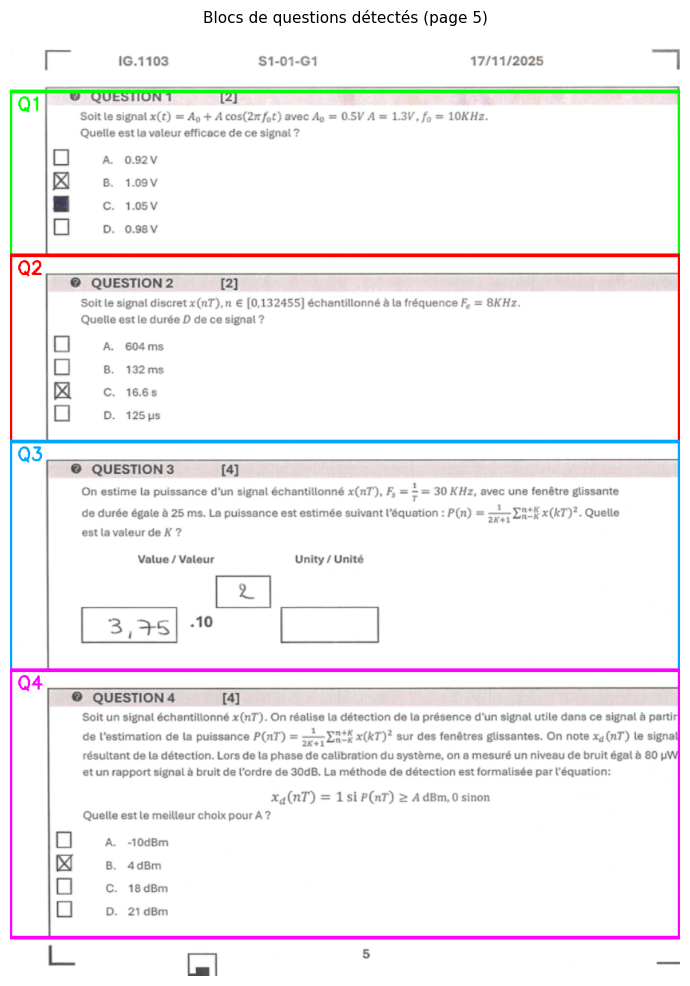

In [ ]:
if len(pages) > EXAM_START:
    # Afficher la détection sur la première page d'examen
    exam_page_img = normalize_page(pages[EXAM_START])
    blocks = detect_question_blocks(exam_page_img)

    print(f'Page {EXAM_START+1} : {len(blocks)} blocs de questions détectés')

    vis_page = exam_page_img.copy()
    for i, (y0, y1) in enumerate(blocks):
        color = [(0, 255, 0), (0, 0, 255), (255, 165, 0), (255, 0, 255)][i % 4]
        cv2.rectangle(vis_page, (0, y0), (exam_page_img.shape[1]-1, y1), color, 3)
        cv2.putText(vis_page, f'Q{i+1}', (10, y0 + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    plt.figure(figsize=(7, 10))
    plt.imshow(cv2.cvtColor(vis_page, cv2.COLOR_BGR2RGB))
    plt.title(f'Blocs de questions détectés (page {EXAM_START+1})', fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
# Parser toutes les pages d'examen
questions = parse_exam_pages(pages, exam_start_page=EXAM_START)
exam_rows = questions_to_exam_rows(questions)

print(f'Total : {len(questions)} questions parsées')

# Afficher un résumé
df_exam = pd.DataFrame(exam_rows)
print(df_exam.to_string(index=False))

Total : 9 questions parsées
 QUESTION  CHOIX A  CHOIX B  CHOIX C  CHOIX D CHOIX E CHOIX F CHOIX G CHOIX H  MANTISSE  EXPOSANT UNITE
        1      NaN      1.0      1.0      NaN    None    None    None    None       NaN       NaN  None
        2      NaN      NaN      1.0      NaN    None    None    None    None       NaN       NaN  None
        3      NaN      NaN      NaN      NaN    None    None    None    None      3.75       2.0  None
        4      NaN      1.0      NaN      NaN    None    None    None    None       NaN       NaN  None
        5      NaN      NaN      NaN      1.0    None    None    None    None       NaN       NaN  None
        6      1.0      1.0      NaN      NaN    None    None    None    None       NaN       NaN  None
        7      NaN      NaN      NaN      1.0    None    None    None    None       NaN       NaN  None
        8      1.0      NaN      NaN      NaN    None    None    None    None       NaN       NaN  None
        9      NaN      NaN      NaN

## 4. Exécution du Programme 2 complet

In [7]:
SIG_DIR_USE = SIG_DIR if os.path.exists(SIG_DIR) else FORM_DIR

t0 = time.time()
generated = autoReadForm(
    pdf_dir=FORM_DIR,
    signatures_dir=SIG_DIR_USE,
    results_dir=RESULTS_DIR,
)
elapsed = time.time() - t0

print(f'\nTemps total : {elapsed:.1f}s pour {len(generated)} formulaires')
print(f'Temps moyen : {elapsed/max(1,len(generated)):.1f}s par formulaire')

[P2] Chargement des signatures depuis : PROJECT 2026 -DATABASE-20260518/SIGNATURES
  -> 60 eleves référencés
[P2] 43 formulaires PDF à traiter dans : PROJECT 2026 -DATABASE-20260518/FORM1
  [PDF] EXAM_FORM1_19283.pdf 

/home/felix/miniforge3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


-> 9 questions, student_id=19283
  [PDF] EXAM_FORM1_36912.pdf -> 9 questions, student_id=36912
  [PDF] EXAM_FORM1_50305.pdf -> 9 questions, student_id=50305
  [PDF] EXAM_FORM1_54331.pdf -> 9 questions, student_id=54331
  [PDF] EXAM_FORM1_58220.pdf -> 9 questions, student_id=58220
  [PDF] EXAM_FORM1_58927.pdf -> 9 questions, student_id=58927
  [PDF] EXAM_FORM1_61856.pdf -> 9 questions, student_id=61856
  [PDF] EXAM_FORM1_61992.pdf -> 9 questions, student_id=61992
  [PDF] EXAM_FORM1_62034.pdf -> 9 questions, student_id=62034
  [PDF] EXAM_FORM1_62288.pdf -> 9 questions, student_id=62288
  [PDF] EXAM_FORM1_62298.pdf -> 9 questions, student_id=62298
  [PDF] EXAM_FORM1_62306.pdf -> 9 questions, student_id=62306
  [PDF] EXAM_FORM1_62336.pdf -> 9 questions, student_id=62336
  [PDF] EXAM_FORM1_62358.pdf -> 8 questions, student_id=62358
  [PDF] EXAM_FORM1_62369.pdf -> 9 questions, student_id=62369
  [PDF] EXAM_FORM1_62370.pdf -> 9 questions, student_id=62372
  [PDF] EXAM_FORM1_62380.pdf -> 9 que

FileNotFoundError: [Errno 2] No such file or directory: 'EXAM_FORM1_RESULTS/EXAM_FORM1_62596.xlsx'

## 5. Vérification d'un fichier xlsx généré

In [ ]:
if generated:
    sample_xlsx = generated[0]
    print(f'Fichier : {os.path.basename(sample_xlsx)}')

    df_p1 = pd.read_excel(sample_xlsx, sheet_name='PAGE-01', header=None)
    print('\n=== Onglet PAGE-01 ===')
    print(df_p1.to_string(index=False, header=False))

    df_ex = pd.read_excel(sample_xlsx, sheet_name='EXAM')
    print('\n=== Onglet EXAM ===')
    print(df_ex.to_string(index=False))

## 6. Vérification du cryptogramme

Le cryptogramme doit être identique sur toutes les pages d'un même formulaire.
C'est la garantie que les pages n'ont pas été mélangées.

In [ ]:
# Comparer les cryptogrammes page par page pour plusieurs PDFs
cryptogram_results = []

for pdf_name in pdf_files[:5]:
    pgs = pdf_to_images(os.path.join(FORM_DIR, pdf_name), dpi=100)
    crypto_ref = extract_cryptogram(normalize_page(pgs[0]))
    crypto_others = []
    for pg in pgs[1:]:
        c = extract_cryptogram(normalize_page(pg))
        if c is not None and c.size > 0:
            crypto_others.append(c)

    valid = compare_cryptograms(crypto_others, crypto_ref) if crypto_others else True
    cryptogram_results.append({'PDF': pdf_name, 'Pages': len(pgs),
                                'Cryptos_verif': len(crypto_others), 'Cohérent': valid})

df_crypto = pd.DataFrame(cryptogram_results)
print(df_crypto.to_string(index=False))

## Bilan Programme 2

| Étape | Méthode | Sortie |
|---|---|---|
| PDF → images | PyMuPDF à 150 DPI | Liste d'images BGR |
| Page 1 | normalize + parse_page1 | 17 champs onglet PAGE-01 |
| Examen (p5→fin) | Hough + CC + OCR | N lignes onglet EXAM |
| Cryptogramme | NCC inter-pages | Validation booléenne |

**Prochaine étape** → `08_evaluation.ipynb` : évaluation quantitative complète.